In [1]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

## Simulating data
We are simulating thirty responses assuming 70% probability of the correct response.

In [2]:
example01_df = pd.DataFrame({'Correct' : np.random.binomial(n=1, p=0.7, size=30)})

## Model definition

$$Correct \sim Bernoulli(p)$$
$$p \sim Beta(8, 3)$$

## Compiling the model

In [3]:
example01_model = cmdstanpy.CmdStanModel(stan_file="Stan/example01.stan")

15:07:22 - cmdstanpy - INFO - compiling stan file C:\Users\ba7dr4\Teaching\_workshops\workshop-stan\Stan\example01.stan to exe file C:\Users\ba7dr4\Teaching\_workshops\workshop-stan\Stan\example01.exe
15:11:30 - cmdstanpy - INFO - compiled model executable: C:\Users\ba7dr4\Teaching\_workshops\workshop-stan\Stan\example01.exe


## Preparing the data in Stan format

In [8]:
example01_standata = {
    "N": len(example01_df),
    "Correct": example01_df.Correct.to_list()
}

## Sampling the model

In [9]:
example01_fit = example01_model.sample(
    data=example01_standata,
    chains=4,
    parallel_chains=os.cpu_count())

15:12:15 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
15:12:15 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:12:16 - cmdstanpy - INFO - CmdStan done processing.


## Extracting samples

In [10]:
example01_samples = example01_fit.draws_pd()

## Plot posterior distribution for probability of correct response

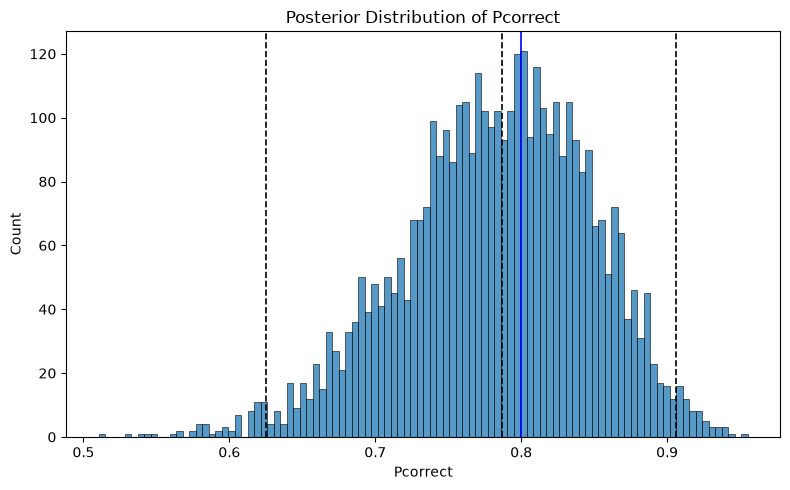

In [15]:
# compute 97% credible interval + median
p_quantiles = np.quantile(example01_samples["p"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example01_samples["p"], bins=100, stat="count")
for x in p_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(example01_df.Correct.mean(), color="blue", linestyle="-", linewidth=1.2)

plt.xlabel("Pcorrect")
plt.ylabel("Count")
plt.title("Posterior Distribution of Pcorrect")
plt.tight_layout()
plt.show()

## Compute probablity that performance is above chance level

In [16]:
np.mean(example01_samples['p'] > 0.5)

np.float64(1.0)